In [2]:
!pip install numpy pandas matplotlib scikit-learn

## 1. Setup & Imports

In [6]:
import sys, subprocess, importlib.util

if importlib.util.find_spec('tensorflow') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'tensorflow'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])

import os, gc, pickle, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.utils import Sequence
import tensorflow.keras.backend as K

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow :', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU        :', len(gpus) > 0, gpus)
print('✓ Libraries loaded')


TensorFlow : 2.18.1
GPU        : True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ Libraries loaded


## 2. Download & Extract WESAD Dataset

In [7]:
# import zipfile, gdown

# FILE_ID    = '1UFik-4se-dZpY6KcH-VXzEOQrRfR_b9l'
# ZIP_PATH   = '/content/WESAD.zip'
# EXTRACT_TO = '/content'

# if not os.path.exists('/content/WESAD'):
#     print('Downloading WESAD dataset...')
#     gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)
#     print('Extracting...')
#     with zipfile.ZipFile(ZIP_PATH, 'r') as z:
#         z.extractall(EXTRACT_TO)
#     print('✓ Done')
# else:
#     print('✓ WESAD already present, skipping download')

# print('Contents:', os.listdir('/content/WESAD'))


## 3. Configuration



In [8]:
DATA_PATH   = 'WESAD'
OUTPUT_PATH = 'WESAD/output_v4'
MODELS_PATH = 'WESAD/output_v4/models'
CACHE_DIR   = 'WESAD/output_v2/subject_cache_v2'   

for d in [OUTPUT_PATH, MODELS_PATH]:
    os.makedirs(d, exist_ok=True)


SAMPLING_RATE       = 700
WRIST_SAMPLING_RATE = 64   
WINDOW_SIZE         = 5 * SAMPLING_RATE         
WRIST_WINDOW_SIZE   = 5 * WRIST_SAMPLING_RATE  
STEP_SIZE           = SAMPLING_RATE // 2        
WRIST_STEP_SIZE     = WRIST_SAMPLING_RATE // 2  
N_CHEST_CHANNELS    = 5    
N_WRIST_CHANNELS    = 6   
N_CHANNELS          = N_CHEST_CHANNELS + N_WRIST_CHANNELS   

VALID_LABELS     = [1, 2, 3, 4]   
TASK_NAME        = 'stress_vs_non_stress'
BINARY_LABEL_MAP = {0: 'non-stress', 1: 'stress'}

# ── Training config ───────────────────────────────────────────────────────────
EPOCHS                  = 80
BATCH_SIZE              = 128
EARLY_STOPPING_PATIENCE = 15    

# ── True Gold Standard split (per fold) ──────────────────────────────────────
# Val-A : 1 subject  → early stopping only
# Val-B : 1 subject  → threshold tuning only
# Test  : 1 subject  → final score (never touched until threshold is fixed)
# Train : remaining 12 subjects
VAL_A_SUBJECTS_PER_FOLD = 1   # early stopping
VAL_B_SUBJECTS_PER_FOLD = 1   # threshold tuning

# ── Augmentation config ───────────────────────────────────────────────────────
AUG_NOISE_STD   = 0.05   # std of Gaussian noise added to each channel
AUG_SCALE_RANGE = (0.85, 1.15)  # random amplitude multiplier

# ── Cache rebuild flag ────────────────────────────────────────────────────────
FORCE_REBUILD = False

n_held_out = 1 + VAL_A_SUBJECTS_PER_FOLD + VAL_B_SUBJECTS_PER_FOLD
print(f'Chest window  : {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLING_RATE:.1f} sec')
print(f'Wrist window  : {WRIST_WINDOW_SIZE} samples = {WRIST_WINDOW_SIZE/WRIST_SAMPLING_RATE:.1f} sec')
print(f'Chest channels: {N_CHEST_CHANNELS}  |  Wrist: {N_WRIST_CHANNELS}  |  Total: {N_CHANNELS}')
print(f'Epochs        : {EPOCHS}  |  ES patience: {EARLY_STOPPING_PATIENCE}')
print(f'Per-fold split: 1 test + {VAL_A_SUBJECTS_PER_FOLD} Val-A (ES) + {VAL_B_SUBJECTS_PER_FOLD} Val-B (threshold) + (N-{n_held_out}) train')
print(f'Task          : {TASK_NAME}')
print()
print('True Gold Standard split per fold:')
print('  Val-A (1 subj) → early stopping only')
print('  Val-B (1 subj) → threshold tuning only   ← separate from Val-A')
print('  Test  (1 subj) → final score')


Chest window  : 3500 samples = 5.0 sec
Wrist window  : 320 samples = 5.0 sec
Chest channels: 5  |  Wrist: 6  |  Total: 11
Epochs        : 80  |  ES patience: 15
Per-fold split: 1 test + 1 Val-A (ES) + 1 Val-B (threshold) + (N-3) train
Task          : stress_vs_non_stress

True Gold Standard split per fold:
  Val-A (1 subj) → early stopping only
  Val-B (1 subj) → threshold tuning only   ← separate from Val-A
  Test  (1 subj) → final score


## 4. Data Loading & Window Extraction


In [9]:
def load_subject(sid, base_path):
    fpath = os.path.join(base_path, sid, sid + '.pkl')
    with open(fpath, 'rb') as f:
        return pickle.load(f, encoding='latin1')


def upsample_signal(sig, orig_rate, target_rate):
    """Linear interpolation to resample a 1-D signal from orig_rate to target_rate."""
    if orig_rate == target_rate:
        return sig
    n_orig   = len(sig)
    n_target = int(round(n_orig * target_rate / orig_rate))
    x_orig   = np.linspace(0, 1, n_orig)
    x_new    = np.linspace(0, 1, n_target)
    return np.interp(x_new, x_orig, sig).astype(np.float32)


def extract_subject_windows(sid, base_path, win_sz, step_sz, keep_labels):
    """
    Slide a window over the subject's 5 chest + 6 wrist signals.
    Fix #4: per-subject z-score computed once before windowing.
    Returns Xc (N, win_sz, 5), Xw (N, wrist_win_sz, 6), y (N,)
    """
    data   = load_subject(sid, base_path)
    chest  = data['signal']['chest']
    wrist  = data['signal']['wrist']
    labels = data['label'].flatten()

    # ── Chest signals (700 Hz) ────────────────────────────────────────────────
    raw_chest = np.column_stack([
        chest['ECG'].flatten(), chest['EDA'].flatten(),
        chest['EMG'].flatten(), chest['Resp'].flatten(),
        chest['Temp'].flatten(),
    ]).astype(np.float32)

    # ── Wrist signals — upsample ACC (32 Hz), EDA & TEMP (4 Hz) → 64 Hz ─────
    acc   = wrist['ACC'].astype(np.float32)
    bvp   = wrist['BVP'].flatten().astype(np.float32)
    w_eda = wrist['EDA'].flatten().astype(np.float32)
    w_tmp = wrist['TEMP'].flatten().astype(np.float32)

    acc_x = upsample_signal(acc[:, 0], 32, WRIST_SAMPLING_RATE)
    acc_y = upsample_signal(acc[:, 1], 32, WRIST_SAMPLING_RATE)
    acc_z = upsample_signal(acc[:, 2], 32, WRIST_SAMPLING_RATE)
    bvp   = upsample_signal(bvp,       64, WRIST_SAMPLING_RATE)
    w_eda = upsample_signal(w_eda,      4, WRIST_SAMPLING_RATE)
    w_tmp = upsample_signal(w_tmp,      4, WRIST_SAMPLING_RATE)

    raw_wrist = np.column_stack([acc_x, acc_y, acc_z, bvp, w_eda, w_tmp]).astype(np.float32)


    raw_chest = (raw_chest - raw_chest.mean(axis=0, keepdims=True)) /                 (raw_chest.std(axis=0,  keepdims=True) + 1e-8)
    raw_wrist = (raw_wrist - raw_wrist.mean(axis=0, keepdims=True)) /                 (raw_wrist.std(axis=0,  keepdims=True) + 1e-8)

    wrist_labels = upsample_signal(
        labels.astype(np.float32), SAMPLING_RATE, WRIST_SAMPLING_RATE
    ).astype(np.int32)

    Xc_list, Xw_list, y_list = [], [], []

    for start in range(0, len(raw_chest) - win_sz, step_sz):
        end          = start + win_sz
        chunk_labels = labels[start:end]
        vals, cnts   = np.unique(chunk_labels, return_counts=True)
        dominant     = int(vals[np.argmax(cnts)])

        if dominant not in keep_labels:
            continue
        if np.max(cnts) / win_sz < 0.5:
            continue

        w_start = int(round(start * WRIST_SAMPLING_RATE / SAMPLING_RATE))
        w_end   = w_start + WRIST_WINDOW_SIZE
        if w_end > len(raw_wrist):
            continue

        Xc_list.append(raw_chest[start:end])
        Xw_list.append(raw_wrist[w_start:w_end])
        y_list.append(dominant)

    return (np.array(Xc_list, dtype=np.float32),
            np.array(Xw_list, dtype=np.float32),
            np.array(y_list,  dtype=np.int32))


subjects = sorted([
    d for d in os.listdir(DATA_PATH)
    if d.startswith('S') and os.path.isdir(os.path.join(DATA_PATH, d))
])
print('Subjects found:', subjects)
print('Total         :', len(subjects))


Subjects found: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Total         : 15


## 5. Cache Windows to Disk (Memory-Safe)

In [10]:
os.makedirs(CACHE_DIR, exist_ok=True)
cache_rows = []

for sid in subjects:
    xc_path = os.path.join(CACHE_DIR, f'{sid}_Xc.npy')
    xw_path = os.path.join(CACHE_DIR, f'{sid}_Xw.npy')
    y_path  = os.path.join(CACHE_DIR, f'{sid}_y.npy')

    if not FORCE_REBUILD and os.path.exists(xc_path) and os.path.exists(y_path):
        y_binary_sid = np.load(y_path)
        print(f'{sid}: loaded from cache  windows={len(y_binary_sid)}')
    else:
        Xc_sid, Xw_sid, y_sid = extract_subject_windows(
            sid, DATA_PATH, WINDOW_SIZE, STEP_SIZE, VALID_LABELS
        )
        y_binary_sid = (y_sid == 2).astype(np.int32)   # stress=1, rest=0
        np.save(xc_path, Xc_sid.astype(np.float32))
        np.save(xw_path, Xw_sid.astype(np.float32))
        np.save(y_path,  y_binary_sid.astype(np.int32))
        print(f'{sid}: extracted & cached  windows={len(y_binary_sid)}')
        del Xc_sid, Xw_sid, y_sid
        gc.collect()

    counts = pd.Series(y_binary_sid).value_counts().sort_index().to_dict()
    cache_rows.append({
        'subject':    sid,
        'n_windows':  int(len(y_binary_sid)),
        'non_stress': int(counts.get(0, 0)),
        'stress':     int(counts.get(1, 0)),
    })
    del y_binary_sid
    gc.collect()

cache_df = pd.DataFrame(cache_rows).sort_values('subject').reset_index(drop=True)
cache_df['stress_ratio'] = (cache_df['stress'] / cache_df['n_windows']).round(3)
subjects_unique = cache_df['subject'].tolist()
cache_df.to_csv(os.path.join(OUTPUT_PATH, 'cnn_subject_cache_summary.csv'), index=False)

print('\n── Cache Summary ──')
print(cache_df[['subject','n_windows','non_stress','stress','stress_ratio']].to_string(index=False))
print(f'\nTotal windows       : {cache_df["n_windows"].sum()}')
print(f'Global stress ratio : {cache_df["stress"].sum()/cache_df["n_windows"].sum():.3f}')


S10: extracted & cached  windows=6146
S11: extracted & cached  windows=6038
S13: extracted & cached  windows=6042
S14: extracted & cached  windows=6042
S15: extracted & cached  windows=6054
S16: extracted & cached  windows=6026
S17: extracted & cached  windows=6014
S2: extracted & cached  windows=5778
S3: extracted & cached  windows=5870
S4: extracted & cached  windows=5940
S5: extracted & cached  windows=6022
S6: extracted & cached  windows=5978
S7: extracted & cached  windows=5976
S8: extracted & cached  windows=6010
S9: extracted & cached  windows=5980

── Cache Summary ──
subject  n_windows  non_stress  stress  stress_ratio
    S10       6146        4696    1450         0.236
    S11       6038        4678    1360         0.225
    S13       6042        4714    1328         0.220
    S14       6042        4692    1350         0.223
    S15       6054        4682    1372         0.227
    S16       6026        4680    1346         0.223
    S17       6014        4568    1446        

## 6. Focal Loss & Model Architecture

In [11]:
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Binary focal loss.
    alpha : prior weight for the positive (stress) class.
    gamma : focusing parameter — higher = more focus on hard examples.
    """
    def _focal(y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce_pos  = -tf.math.log(y_pred)
        ce_neg  = -tf.math.log(1.0 - y_pred)
        fl_pos  = alpha       * tf.pow(1.0 - y_pred, gamma) * ce_pos
        fl_neg  = (1 - alpha) * tf.pow(y_pred,        gamma) * ce_neg
        loss    = y_true * fl_pos + (1.0 - y_true) * fl_neg
        return tf.reduce_mean(loss)
    return _focal


def build_1d_cnn_binary(chest_shape, wrist_shape):
    """
    Dual-stream 1D CNN for binary stress detection.
      Chest stream  — 3 conv blocks (32→64→128 filters), kernel sizes 31/15/7
      Wrist stream  — 3 conv blocks (32→64→128 filters), kernel sizes 15/7/5
      Fusion        — GlobalAvgPool each stream → concatenate → Dense 64 → 1
    """
    reg = tf.keras.regularizers.l2(1e-4)

    # ── Chest stream ──────────────────────────────────────────────────────────
    chest_in = tf.keras.Input(shape=chest_shape, name='chest_input')

    x = Conv1D(32, kernel_size=31, activation='relu', padding='same',
               kernel_regularizer=reg)(chest_in)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=4)(x)   # 3500 → 875
    x = Dropout(0.3)(x)

    x = Conv1D(64, kernel_size=15, activation='relu', padding='same',
               kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=4)(x)   # 875 → 218
    x = Dropout(0.4)(x)

    x = Conv1D(128, kernel_size=7, activation='relu', padding='same',
               kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=4)(x)   # 218 → 54
    x = Dropout(0.5)(x)

    chest_out = GlobalAveragePooling1D(name='chest_gap')(x)

    # ── Wrist stream ───────────────────────────────────────────────────────────
    wrist_in = tf.keras.Input(shape=wrist_shape, name='wrist_input')

    w = Conv1D(32, kernel_size=15, activation='relu', padding='same',
               kernel_regularizer=reg)(wrist_in)
    w = BatchNormalization()(w)
    w = MaxPooling1D(pool_size=2)(w)   # 320 → 160
    w = Dropout(0.3)(w)

    w = Conv1D(64, kernel_size=7, activation='relu', padding='same',
               kernel_regularizer=reg)(w)
    w = BatchNormalization()(w)
    w = MaxPooling1D(pool_size=2)(w)   # 160 → 80
    w = Dropout(0.4)(w)

    w = Conv1D(128, kernel_size=5, activation='relu', padding='same',
               kernel_regularizer=reg)(w)
    w = BatchNormalization()(w)
    w = MaxPooling1D(pool_size=2)(w)   # 80 → 40
    w = Dropout(0.5)(w)

    wrist_out = GlobalAveragePooling1D(name='wrist_gap')(w)

    # ── Fusion head ────────────────────────────────────────────────────────────
    merged = tf.keras.layers.Concatenate(name='fusion')([chest_out, wrist_out])
    out    = Dense(64, activation='relu', kernel_regularizer=reg)(merged)
    out    = Dropout(0.5)(out)
    out    = Dense(1, activation='sigmoid')(out)

    model = tf.keras.Model(
        inputs=[chest_in, wrist_in],
        outputs=out,
        name='DualStream_1DCNN'
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model


demo = build_1d_cnn_binary(
    chest_shape=(WINDOW_SIZE,       N_CHEST_CHANNELS),
    wrist_shape=(WRIST_WINDOW_SIZE, N_WRIST_CHANNELS)
)
demo.summary()
print(f'\nTotal trainable params: {demo.count_params():,}')
del demo


2026-04-30 21:56:44.676620: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-30 21:56:44.676880: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-30 21:56:44.677555: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1777611404.678029 23950766 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1777611404.678822 23950766 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "DualStream_1DCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ chest_input         │ (None, 3500, 5)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wrist_input         │ (None, 320, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3500, 32)  │      4,992 │ chest_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 320, 32)   │      2,912 │ wrist_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3500, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 32)   │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 875, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 160, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 875, 32)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 160, 32)   │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 875, 64)   │     30,784 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 160, 64)   │     14,400 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 875, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 218, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 80, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 218, 64)   │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 80, 64)    │          0 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 218, 128)  │     57,472 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 80, 128)   │     41,088 │ dropout_4[0][0] 

 Total params: 169,953 (663.88 KB)

 Trainable params: 169,057 (660.38 KB)

 Non-trainable params: 896 (3.50 KB)


Total trainable params: 169,953


## 7. Memory-Safe Data Generator with Augmentation

In [12]:
class NpyBatchSequence(Sequence):
    """
    Streams cached .npy windows in mini-batches.
    Fix #1  : shuffle seed increments each epoch.
    Fix #8  : optional online augmentation (noise + amplitude jitter).
    Yields  : ([chest_batch, wrist_batch], y_batch) for the dual-stream model.
    """
    def __init__(self, cache_dir, batch_specs, shuffle=False, augment=False):
        self.cache_dir   = cache_dir
        self.batch_specs = list(batch_specs)
        self.shuffle     = shuffle
        self.augment     = augment
        self._xc_cache   = {}
        self._xw_cache   = {}
        self._y_cache    = {}
        self._epoch      = 0
        if self.shuffle:
            self._do_shuffle()

    def _get_arrays(self, sid):
        if sid not in self._xc_cache:
            self._xc_cache[sid] = np.load(
                os.path.join(self.cache_dir, f'{sid}_Xc.npy'), mmap_mode='r')
            self._xw_cache[sid] = np.load(
                os.path.join(self.cache_dir, f'{sid}_Xw.npy'), mmap_mode='r')
            self._y_cache[sid]  = np.load(
                os.path.join(self.cache_dir, f'{sid}_y.npy'),  mmap_mode='r')
        return self._xc_cache[sid], self._xw_cache[sid], self._y_cache[sid]

    def __len__(self):
        return len(self.batch_specs)

    def __getitem__(self, idx):
        sid, start, end = self.batch_specs[idx]
        Xc, Xw, y = self._get_arrays(sid)
        Xc_batch = np.asarray(Xc[start:end], dtype=np.float32)
        Xw_batch = np.asarray(Xw[start:end], dtype=np.float32)
        y_batch  = np.asarray(y[start:end],  dtype=np.float32)

        if self.augment:
            rng = np.random.default_rng(SEED + self._epoch * 100000 + idx)
            Xc_batch = Xc_batch + rng.normal(
                0, AUG_NOISE_STD, size=Xc_batch.shape).astype(np.float32)
            Xw_batch = Xw_batch + rng.normal(
                0, AUG_NOISE_STD, size=Xw_batch.shape).astype(np.float32)
            scales_c = rng.uniform(
                AUG_SCALE_RANGE[0], AUG_SCALE_RANGE[1],
                size=(Xc_batch.shape[0], 1, Xc_batch.shape[2])
            ).astype(np.float32)
            scales_w = rng.uniform(
                AUG_SCALE_RANGE[0], AUG_SCALE_RANGE[1],
                size=(Xw_batch.shape[0], 1, Xw_batch.shape[2])
            ).astype(np.float32)
            Xc_batch = Xc_batch * scales_c
            Xw_batch = Xw_batch * scales_w

        return (Xc_batch, Xw_batch), y_batch

    def _do_shuffle(self):
        np.random.default_rng(SEED + self._epoch).shuffle(self.batch_specs)

    def on_epoch_end(self):
        self._epoch += 1
        if self.shuffle:
            self._do_shuffle()


def build_batch_specs(subject_ids, cache_dir, batch_size):
    specs = []
    for sid in subject_ids:
        n = len(np.load(os.path.join(cache_dir, f'{sid}_y.npy'), mmap_mode='r'))
        for start in range(0, n, batch_size):
            specs.append((sid, start, min(start + batch_size, n)))
    return specs


def load_subject_labels(cache_dir, sid):
    return np.load(os.path.join(cache_dir, f'{sid}_y.npy'))


def find_best_f1_threshold(y_true, y_prob, search_range=np.arange(0.01, 1.00, 0.01)):
    """
    Sweep thresholds and return the one that maximises binary F1.
    Used inside each fold on the validation subjects (Phase 1).
    """
    best_thresh, best_f1 = 0.5, 0.0
    for t in search_range:
        preds = (y_prob >= t).astype(int)
        f1    = f1_score(y_true, preds, average='binary', zero_division=0)
        if f1 > best_f1:
            best_f1    = f1
            best_thresh = t
    return float(best_thresh), float(best_f1)


print('✓ Generator, helpers, and find_best_f1_threshold() defined.')


✓ Generator, helpers, and find_best_f1_threshold() defined.


## 8. Phase 1 — LOSO Training Loop with True Val-A / Val-B / Test Split


In [13]:
def make_cosine_lr_callback(total_epochs, initial_lr=1e-3, min_lr=1e-6, n_cycles=3):
    """LR schedule independent of val loss — no reaction to val noise."""
    cycle_len = total_epochs // n_cycles

    def schedule(epoch, lr):
        cycle_epoch = epoch % cycle_len
        return float(min_lr + 0.5 * (initial_lr - min_lr) * (1 + np.cos(np.pi * cycle_epoch / cycle_len)))

    return LearningRateScheduler(schedule, verbose=0)


# ── Phase 1 accumulators ──────────────────────────────────────────────────────
loso_results    = []   # per-fold dicts
all_true        = []   # test labels pooled (for Phase 3 re-evaluation)
all_prob        = []   # test probabilities pooled
fold_thresholds = []   # Phase 1: best Val-B threshold per fold
fold_f1_scores  = []   # Phase 1: test F1 at that fold threshold
fold_acc_scores = []   # Phase 1: test accuracy at that fold threshold
best_model_info = {'f1': -1.0, 'subject': None, 'path': None, 'acc': None}

# Separate RNGs so Val-A and Val-B selections are independently reproducible
rng_val_a = np.random.default_rng(SEED)
rng_val_b = np.random.default_rng(SEED + 1)

print(f'Running LOSO over {len(subjects_unique)} subjects (True Gold Standard — Val-A / Val-B / Test)...')
print()
print('Per fold:  Train (12) | Val-A (1) → early stopping | Val-B (1) → threshold | Test (1) → score')
print('─' * 80)

for fold_i, test_subj in enumerate(subjects_unique, start=1):

    # ── Split ─────────────────────────────────────────────────────────────────
    # Val-A: early stopping
    candidates_a  = [s for s in subjects_unique if s != test_subj]
    val_a_subjects = list(rng_val_a.choice(candidates_a, size=VAL_A_SUBJECTS_PER_FOLD, replace=False))

    # Val-B: threshold tuning — must not overlap with Val-A or Test
    candidates_b  = [s for s in subjects_unique if s != test_subj and s not in val_a_subjects]
    val_b_subjects = list(rng_val_b.choice(candidates_b, size=VAL_B_SUBJECTS_PER_FOLD, replace=False))

    train_subjects = [s for s in subjects_unique
                      if s != test_subj
                      and s not in val_a_subjects
                      and s not in val_b_subjects]

    print(f'Fold {fold_i:2d}/{len(subjects_unique)}')
    print(f'  test  = {test_subj}')
    print(f'  Val-A = {val_a_subjects}  (early stopping)')
    print(f'  Val-B = {val_b_subjects}  (threshold tuning)')
    print(f'  train = {len(train_subjects)} subjects: {train_subjects}')

    # ── Generators ────────────────────────────────────────────────────────────
    train_seq  = NpyBatchSequence(
        CACHE_DIR, build_batch_specs(train_subjects, CACHE_DIR, BATCH_SIZE),
        shuffle=True, augment=True)
    val_a_seq  = NpyBatchSequence(                                 # early stopping
        CACHE_DIR, build_batch_specs(val_a_subjects, CACHE_DIR, BATCH_SIZE),
        shuffle=False, augment=False)
    val_b_seq  = NpyBatchSequence(                                 # threshold tuning
        CACHE_DIR, build_batch_specs(val_b_subjects, CACHE_DIR, BATCH_SIZE),
        shuffle=False, augment=False)
    test_seq   = NpyBatchSequence(
        CACHE_DIR, build_batch_specs([test_subj], CACHE_DIR, BATCH_SIZE),
        shuffle=False, augment=False)

    # ── Class weights (train subjects only) ───────────────────────────────────
    y_train_all = np.concatenate(
        [load_subject_labels(CACHE_DIR, s) for s in train_subjects]).astype(int)
    fold_cw = compute_class_weight(
        class_weight='balanced', classes=np.unique(y_train_all), y=y_train_all)
    cw_dict = {int(c): float(w) for c, w in zip(np.unique(y_train_all), fold_cw)}
    print(f'  class weights : {cw_dict}')

    # ── Build & train model — Val-A drives early stopping ─────────────────────
    model = build_1d_cnn_binary(
        chest_shape=(WINDOW_SIZE,       N_CHEST_CHANNELS),
        wrist_shape=(WRIST_WINDOW_SIZE, N_WRIST_CHANNELS)
    )
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE,
                      restore_best_weights=True, verbose=1),   # Val-A only
        make_cosine_lr_callback(total_epochs=EPOCHS, initial_lr=1e-3, min_lr=1e-6, n_cycles=3)
    ]
    history = model.fit(
        train_seq,
        epochs=EPOCHS,
        validation_data=val_a_seq,    # ← Val-A: early stopping only
        class_weight=cw_dict,
        callbacks=callbacks,
        verbose=1
    )
    print(f'  Training stopped at epoch {len(history.history["loss"])} '
          f'(Val-A best val_loss)')

    # ── Step 3: Find fold threshold on Val-B (clean, never seen during training)
    y_val_b   = np.concatenate(
        [load_subject_labels(CACHE_DIR, s) for s in val_b_subjects]).astype(int)
    y_val_b_prob = model.predict(val_b_seq, verbose=0).ravel()

    fold_thresh, val_b_f1 = find_best_f1_threshold(y_val_b, y_val_b_prob)
    print(f'  ✓ Val-B threshold : {fold_thresh:.4f}  (Val-B F1 = {val_b_f1:.4f})')

    # ── Step 4: Apply threshold to Test subject ────────────────────────────────
    y_true   = load_subject_labels(CACHE_DIR, test_subj).astype(int)
    y_prob_t = model.predict(test_seq, verbose=0).ravel()

    y_pred = (y_prob_t >= fold_thresh).astype(int)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, average='binary', zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob_t)
    except Exception:
        auc = float('nan')

    # ── Step 5: Record ────────────────────────────────────────────────────────
    fold_thresholds.append(fold_thresh)
    fold_f1_scores.append(f1)
    fold_acc_scores.append(acc)

    all_true.extend(y_true.tolist())
    all_prob.extend(y_prob_t.tolist())

    loso_results.append({
        'subject':        test_subj,
        'val_a':          str(val_a_subjects),
        'val_b':          str(val_b_subjects),
        'fold_threshold': round(fold_thresh, 4),
        'acc':            round(float(acc),  4),
        'f1':             round(float(f1),   4),
        'auc':            round(float(auc),  4),
        'val_b_f1':       round(float(val_b_f1), 4),
        'n_test':         int(len(y_true)),
        'epochs_ran':     len(history.history['loss']),
        'approach':       'CNN_v4_TrueGoldStd',
        'task':           TASK_NAME
    })

    print(f'  → acc={acc:.4f} | f1={f1:.4f} | auc={auc:.4f} '
          f'| threshold={fold_thresh:.4f} | epochs={len(history.history["loss"])}')

    # ── Save fold model ────────────────────────────────────────────────────────
    fold_model_path = os.path.join(MODELS_PATH, f'cnn_fold_{test_subj}.keras')
    model.save(fold_model_path)
    print(f'  ✓ model saved : {fold_model_path}')

    if f1 > best_model_info['f1']:
        best_model_info.update({'f1': f1, 'acc': acc,
                                 'subject': test_subj, 'path': fold_model_path})
        best_path = os.path.join(MODELS_PATH, 'best_fold_model.keras')
        model.save(best_path)
        print(f'  ★ new best (f1={f1:.4f}) → saved as best_fold_model.keras')

    print()
    del (train_seq, val_a_seq, val_b_seq, test_seq,
         y_train_all, y_val_b, y_val_b_prob,
         y_true, y_prob_t, y_pred, model, history)
    tf.keras.backend.clear_session()
    gc.collect()

print('\n✓ Phase 1 complete — all folds trained and evaluated.')
print(f'Best fold subject : {best_model_info["subject"]}  '
      f'F1={best_model_info["f1"]:.4f}  Acc={best_model_info["acc"]:.4f}')


Running LOSO over 15 subjects (True Gold Standard — Val-A / Val-B / Test)...

Per fold:  Train (12) | Val-A (1) → early stopping | Val-B (1) → threshold | Test (1) → score
────────────────────────────────────────────────────────────────────────────────
Fold  1/15
  test  = S10
  Val-A = [np.str_('S13')]  (early stopping)
  Val-B = [np.str_('S3')]  (threshold tuning)
  train = 12 subjects: ['S11', 'S14', 'S15', 'S16', 'S17', 'S2', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
  class weights : {0: 0.6417726493283795, 1: 2.2633866700264584}
Epoch 1/80


2026-04-30 21:57:02.452128: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


568/568 ━━━━━━━━━━━━━━━━━━━━ 50s 77ms/step - accuracy: 0.6881 - loss: 0.4808 - val_accuracy: 0.7651 - val_loss: 0.2560 - learning_rate: 0.0010
Epoch 2/80
568/568 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.7680 - loss: 0.1831 - val_accuracy: 0.7592 - val_loss: 0.1077 - learning_rate: 9.9636e-04
Epoch 3/80
568/568 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step - accuracy: 0.7777 - loss: 0.1291 - val_accuracy: 0.7608 - val_loss: 0.1256 - learning_rate: 9.8549e-04
Epoch 4/80
568/568 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.7963 - loss: 0.1236 - val_accuracy: 0.7754 - val_loss: 0.0967 - learning_rate: 9.6754e-04
Epoch 5/80
568/568 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step - accuracy: 0.7958 - loss: 0.1173 - val_accuracy: 0.9563 - val_loss: 0.0706 - learning_rate: 9.4279e-04
Epoch 6/80
568/568 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.8033 - loss: 0.1439 - val_accuracy: 0.6895 - val_loss: 0.1440 - learning_rate: 9.1158e-04
Epoch 7/80
568/568 ━━━━━━━━━━━━━━━━━━━━ 33s 57ms/step - accuracy: 0

## 9. Phase 2 — Aggregate Cross-Validation Statistics

In [14]:
# ── Phase 2: Aggregate stats ──────────────────────────────────────────────────
results_df = pd.DataFrame(loso_results)

fold_thresholds_arr = np.array(fold_thresholds)
fold_f1_arr         = np.array(fold_f1_scores)
fold_acc_arr        = np.array(fold_acc_scores)

mean_threshold = float(np.mean(fold_thresholds_arr))
std_threshold  = float(np.std(fold_thresholds_arr))
mean_f1        = float(np.mean(fold_f1_arr))
std_f1         = float(np.std(fold_f1_arr))
mean_acc       = float(np.mean(fold_acc_arr))
std_acc        = float(np.std(fold_acc_arr))
mean_auc       = float(results_df['auc'].mean())
std_auc        = float(results_df['auc'].std())

print('═' * 70)
print('PHASE 2 — GOLD STANDARD AGGREGATE RESULTS')
print('═' * 70)
print()
print('Per-fold results (fold-specific threshold applied to each test subject):')
print(results_df[['subject','fold_threshold','acc','f1','auc','val_b_f1','epochs_ran']].to_string(index=False))
print()
print('─' * 70)
print('Summary:')
print(f'  Mean Accuracy  : {mean_acc:.4f} ± {std_acc:.4f}')
print(f'  Mean F1        : {mean_f1:.4f} ± {std_f1:.4f}')
print(f'  Mean AUC       : {mean_auc:.4f} ± {std_auc:.4f}')
print()
print(f'  Mean Threshold : {mean_threshold:.4f}')
print(f'  Std Threshold  : {std_threshold:.4f}  ', end='')
if std_threshold < 0.05:
    print('→ LOW — threshold is stable and reliable for a generic model ✓')
elif std_threshold < 0.10:
    print('→ MODERATE — threshold is reasonably stable across subjects')
else:
    print('→ HIGH — model is sensitive to who is in the training set; '
          'a locked generic threshold may underperform')

results_df.to_csv(os.path.join(OUTPUT_PATH, 'cnn_phase2_per_fold_results.csv'), index=False)

# Phase 2 summary row
phase2_summary = pd.DataFrame([{
    'approach':         'CNN_v4_TrueGoldStd',
    'task':             TASK_NAME,
    'phase':            'Phase2_FoldThresholds',
    'mean_threshold':   round(mean_threshold, 4),
    'std_threshold':    round(std_threshold,  4),
    'mean_accuracy':    round(mean_acc,  4),
    'std_accuracy':     round(std_acc,   4),
    'mean_f1':          round(mean_f1,   4),
    'std_f1':           round(std_f1,    4),
    'mean_auc':         round(mean_auc,  4),
    'std_auc':          round(std_auc,   4),
    'n_subjects':       len(results_df)
}])
phase2_summary.to_csv(os.path.join(OUTPUT_PATH, 'cnn_phase2_summary.csv'), index=False)
print()
print('✓ Phase 2 results saved.')


══════════════════════════════════════════════════════════════════════
PHASE 2 — GOLD STANDARD AGGREGATE RESULTS
══════════════════════════════════════════════════════════════════════

Per-fold results (fold-specific threshold applied to each test subject):
subject  fold_threshold    acc     f1    auc  val_b_f1  epochs_ran
    S10            0.52 0.9893 0.9777 1.0000    0.6495          20
    S11            0.30 0.9296 0.8456 0.9688    1.0000          48
    S13            0.38 0.8883 0.7001 0.7030    0.6698          22
    S14            0.36 0.7575 0.6022 0.8744    0.7920          22
    S15            0.54 0.9906 0.9788 0.9999    0.5131          17
    S16            0.39 0.9179 0.7747 0.6839    1.0000          25
    S17            0.43 0.8284 0.6097 0.8412    0.7203          19
     S2            0.61 0.9573 0.8884 0.9994    0.9834          23
     S3            0.44 0.6569 0.5054 0.8161    0.9843          29
     S4            0.33 0.8143 0.6429 0.8249    0.4521          46
     

### 9a. Threshold Stability Visualisation

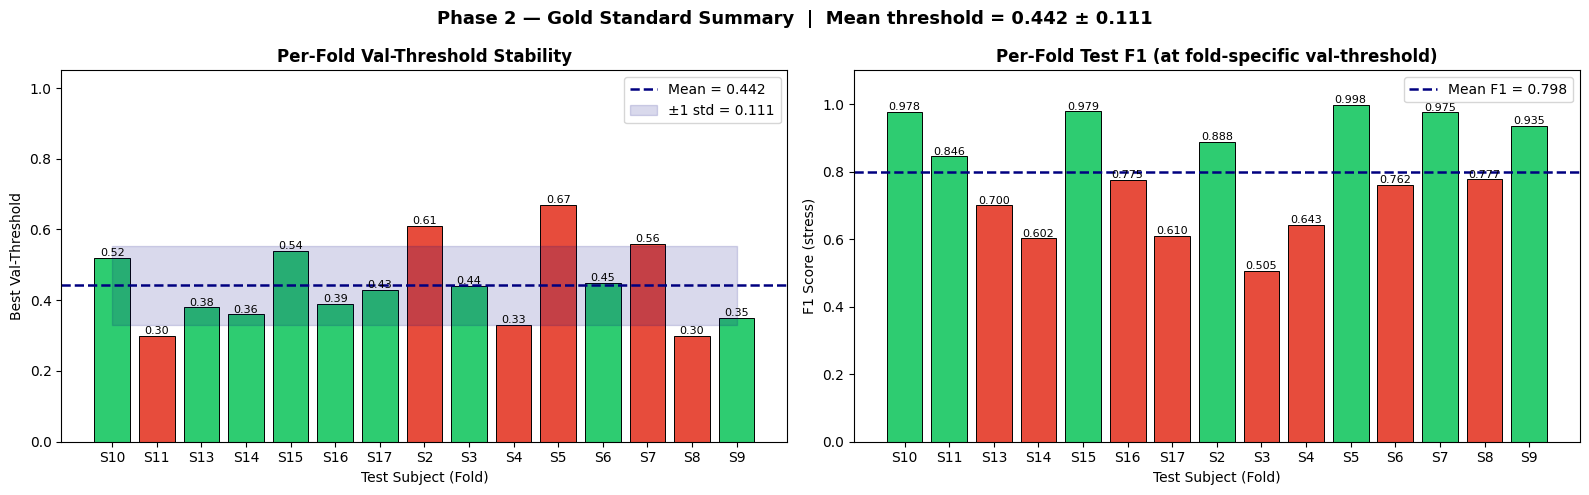

✓ Saved: phase2_threshold_stability.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: per-fold threshold bar chart ────────────────────────────────────────
ax = axes[0]
colors = ['#2ecc71' if abs(t - mean_threshold) <= std_threshold else '#e74c3c'
          for t in fold_thresholds_arr]
bars = ax.bar(results_df['subject'], fold_thresholds_arr,
              color=colors, edgecolor='black', linewidth=0.7)
ax.axhline(mean_threshold, color='navy', linestyle='--', lw=1.8,
           label=f'Mean = {mean_threshold:.3f}')
ax.fill_between(range(len(results_df)),
                mean_threshold - std_threshold,
                mean_threshold + std_threshold,
                alpha=0.15, color='navy', label=f'±1 std = {std_threshold:.3f}')
for bar, val in zip(bars, fold_thresholds_arr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', fontsize=8)
ax.set_xlabel('Test Subject (Fold)')
ax.set_ylabel('Best Val-Threshold')
ax.set_title('Per-Fold Val-Threshold Stability', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend()

# ── Right: per-fold F1 bar chart ──────────────────────────────────────────────
ax = axes[1]
mean_f1_plot = fold_f1_arr.mean()
colors_f1 = ['#2ecc71' if v >= mean_f1_plot else '#e74c3c' for v in fold_f1_arr]
bars2 = ax.bar(results_df['subject'], fold_f1_arr,
               color=colors_f1, edgecolor='black', linewidth=0.7)
ax.axhline(mean_f1_plot, color='navy', linestyle='--', lw=1.8,
           label=f'Mean F1 = {mean_f1_plot:.3f}')
for bar, val in zip(bars2, fold_f1_arr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=8)
ax.set_xlabel('Test Subject (Fold)')
ax.set_ylabel('F1 Score (stress)')
ax.set_title('Per-Fold Test F1 (at fold-specific val-threshold)', fontweight='bold')
ax.set_ylim(0, 1.10)
ax.legend()

plt.suptitle(f'Phase 2 — Gold Standard Summary  |  Mean threshold = {mean_threshold:.3f} ± {std_threshold:.3f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'phase2_threshold_stability.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: phase2_threshold_stability.png')


## 10. Phase 3 — Honest "Locked Generic" Threshold Re-Evaluation

In [17]:
# ── Phase 3: Re-evaluate all folds at the single locked threshold ─────────────
LOCKED_THRESHOLD = mean_threshold   # exact mean — no rounding
print(f'Locked generic threshold : {LOCKED_THRESHOLD:.6f}')
print(f'  (exact mean of per-fold val thresholds, no rounding applied)')
print()

all_true_arr = np.array(all_true)
all_prob_arr = np.array(all_prob)

phase3_rows = []
offset = 0
for row in loso_results:
    n       = row['n_test']
    yt      = all_true_arr[offset:offset+n]
    yprob   = all_prob_arr[offset:offset+n]
    yp      = (yprob >= LOCKED_THRESHOLD).astype(int)

    acc_p3  = accuracy_score(yt, yp)
    f1_p3   = f1_score(yt, yp, average='binary', zero_division=0)
    try:
        auc_p3 = roc_auc_score(yt, yprob)
    except Exception:
        auc_p3 = float('nan')

    phase3_rows.append({
        'subject':          row['subject'],
        'locked_threshold': LOCKED_THRESHOLD,
        'acc_phase3':       round(float(acc_p3), 4),
        'f1_phase3':        round(float(f1_p3),  4),
        'auc_phase3':       round(float(auc_p3), 4),
        'acc_phase1':       row['acc'],
        'f1_phase1':        row['f1'],
        'fold_threshold':   row['fold_threshold'],
        'n_test':           n,
        'approach':         'CNN_v4_TrueGoldStd',
        'task':             TASK_NAME
    })
    offset += n

phase3_df = pd.DataFrame(phase3_rows)

mean_acc_p3 = phase3_df['acc_phase3'].mean()
std_acc_p3  = phase3_df['acc_phase3'].std()
mean_f1_p3  = phase3_df['f1_phase3'].mean()
std_f1_p3   = phase3_df['f1_phase3'].std()
mean_auc_p3 = phase3_df['auc_phase3'].mean()

print('═' * 70)
print(f'PHASE 3 — LOCKED GENERIC THRESHOLD = {LOCKED_THRESHOLD}')
print('═' * 70)
print()
print('Per-subject results:')
print(phase3_df[['subject','locked_threshold','acc_phase3','f1_phase3','auc_phase3',
                  'acc_phase1','f1_phase1']].to_string(index=False))
print()
print('─' * 70)
print(f'Phase 3 (locked)  Mean Accuracy : {mean_acc_p3:.4f} ± {std_acc_p3:.4f}')
print(f'Phase 3 (locked)  Mean F1       : {mean_f1_p3:.4f} ± {std_f1_p3:.4f}')
print(f'Phase 3 (locked)  Mean AUC      : {mean_auc_p3:.4f}')
print()
print('─' * 70)
print('Comparison: Phase 1 (fold-specific thresh) vs Phase 3 (locked thresh):')
print(f'  Phase 1  Mean F1  : {mean_f1:.4f} ± {std_f1:.4f}  ← optimistic upper bound')
print(f'  Phase 3  Mean F1  : {mean_f1_p3:.4f} ± {std_f1_p3:.4f}  ← honest generic result')
delta = mean_f1 - mean_f1_p3
print(f"  Delta             : {delta:.4f}  ({'small — generic model is viable ✓' if abs(delta) < 0.03 else 'notable — per-subject tuning helps considerably'})")

phase3_df.to_csv(os.path.join(OUTPUT_PATH, 'cnn_phase3_locked_threshold.csv'), index=False)

phase3_summary = pd.DataFrame([{
    'approach':          'CNN_v4_TrueGoldStd',
    'task':              TASK_NAME,
    'phase':             'Phase3_LockedThreshold',
    'locked_threshold':  LOCKED_THRESHOLD,
    'mean_accuracy':     round(mean_acc_p3, 4),
    'std_accuracy':      round(std_acc_p3,  4),
    'mean_f1':           round(mean_f1_p3,  4),
    'std_f1':            round(std_f1_p3,   4),
    'mean_auc':          round(mean_auc_p3, 4),
    'n_subjects':        len(phase3_df)
}])
phase3_summary.to_csv(os.path.join(OUTPUT_PATH, 'cnn_phase3_summary.csv'), index=False)
print('\n✓ Phase 3 results saved.')


Locked generic threshold : 0.442000
  (exact mean of per-fold val thresholds, no rounding applied)

══════════════════════════════════════════════════════════════════════
PHASE 3 — LOCKED GENERIC THRESHOLD = 0.442
══════════════════════════════════════════════════════════════════════

Per-subject results:
subject  locked_threshold  acc_phase3  f1_phase3  auc_phase3  acc_phase1  f1_phase1
    S10             0.442      0.9116     0.8423      1.0000      0.9893     0.9777
    S11             0.442      0.9016     0.7420      0.9688      0.9296     0.8456
    S13             0.442      0.8990     0.7027      0.7030      0.8883     0.7001
    S14             0.442      0.9025     0.7277      0.8744      0.7575     0.6022
    S15             0.442      0.9575     0.9144      0.9999      0.9906     0.9788
    S16             0.442      0.9169     0.7713      0.6839      0.9179     0.7747
    S17             0.442      0.8668     0.6578      0.8412      0.8284     0.6097
     S2             0

### 10a. Phase 1 vs Phase 3 F1 Comparison per Subject

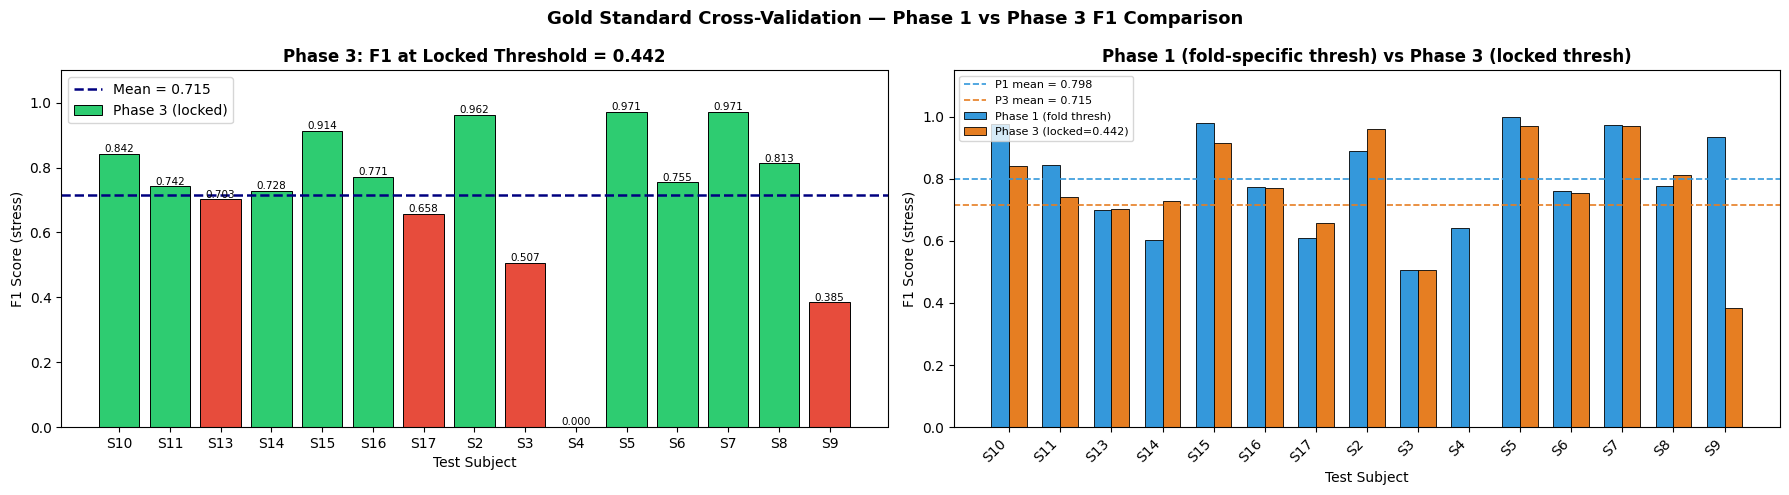

✓ Saved: phase3_f1_comparison.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── Phase 3 F1 bar chart ──────────────────────────────────────────────────────
ax = axes[0]
colors_p3 = ['#2ecc71' if v >= mean_f1_p3 else '#e74c3c' for v in phase3_df['f1_phase3']]
bars = ax.bar(phase3_df['subject'], phase3_df['f1_phase3'],
              color=colors_p3, edgecolor='black', linewidth=0.7, label='Phase 3 (locked)')
ax.axhline(mean_f1_p3, color='navy', linestyle='--', lw=1.8,
           label=f'Mean = {mean_f1_p3:.3f}')
for bar, val in zip(bars, phase3_df['f1_phase3']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=7.5)
ax.set_xlabel('Test Subject')
ax.set_ylabel('F1 Score (stress)')
ax.set_title(f'Phase 3: F1 at Locked Threshold = {LOCKED_THRESHOLD}', fontweight='bold')
ax.set_ylim(0, 1.10)
ax.legend()

# ── Phase 1 vs Phase 3 grouped bar chart ──────────────────────────────────────
ax = axes[1]
x    = np.arange(len(phase3_df))
w    = 0.35
ax.bar(x - w/2, phase3_df['f1_phase1'], width=w, label=f'Phase 1 (fold thresh)',
       color='#3498db', edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, phase3_df['f1_phase3'], width=w, label=f'Phase 3 (locked={LOCKED_THRESHOLD})',
       color='#e67e22', edgecolor='black', linewidth=0.6)
ax.axhline(mean_f1,    color='#3498db', linestyle='--', lw=1.2,
           label=f'P1 mean = {mean_f1:.3f}')
ax.axhline(mean_f1_p3, color='#e67e22', linestyle='--', lw=1.2,
           label=f'P3 mean = {mean_f1_p3:.3f}')
ax.set_xticks(x)
ax.set_xticklabels(phase3_df['subject'], rotation=45, ha='right')
ax.set_xlabel('Test Subject')
ax.set_ylabel('F1 Score (stress)')
ax.set_title('Phase 1 (fold-specific thresh) vs Phase 3 (locked thresh)', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=8)

plt.suptitle('Gold Standard Cross-Validation — Phase 1 vs Phase 3 F1 Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'phase3_f1_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: phase3_f1_comparison.png')


## 11. Classification Report & Confusion Matrix (Phase 3 — Locked Threshold)

Classification Report  (locked threshold = 0.442)
───────────────────────────────────────────────────────
              precision  recall  f1-score     support
non-stress       0.9238  0.9353    0.9295  69984.0000
stress           0.7624  0.7292    0.7454  19932.0000
accuracy         0.8896  0.8896    0.8896      0.8896
macro avg        0.8431  0.8323    0.8375  89916.0000
weighted avg     0.8880  0.8896    0.8887  89916.0000


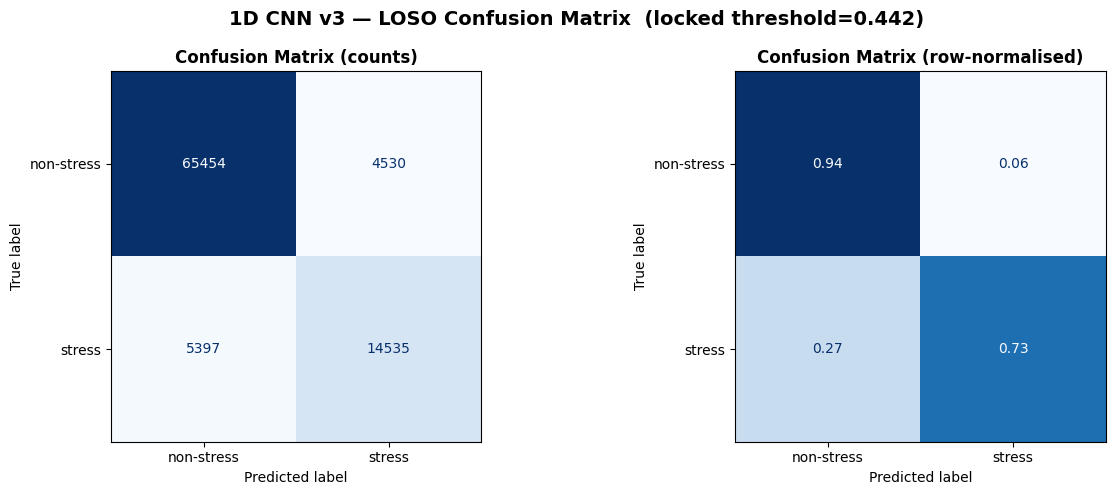

In [19]:
all_pred_p3 = (all_prob_arr >= LOCKED_THRESHOLD).astype(int)

print(f'Classification Report  (locked threshold = {LOCKED_THRESHOLD})')
print('─' * 55)
report_dict = classification_report(
    all_true_arr, all_pred_p3,
    target_names=['non-stress', 'stress'],
    output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
print(report_df.round(4))
report_df.to_csv(os.path.join(OUTPUT_PATH,
    f'cnn_report_locked_thresh_{LOCKED_THRESHOLD:.4f}.csv'))

cm      = confusion_matrix(all_true_arr, all_pred_p3)
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(cm, display_labels=['non-stress','stress']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')

ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=['non-stress','stress']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (row-normalised)', fontweight='bold')

fig.suptitle(f'1D CNN v3 — LOSO Confusion Matrix  (locked threshold={LOCKED_THRESHOLD})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, f'cm_locked_{LOCKED_THRESHOLD:.4f}.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## 12. ROC Curve (Pooled LOSO Probabilities)

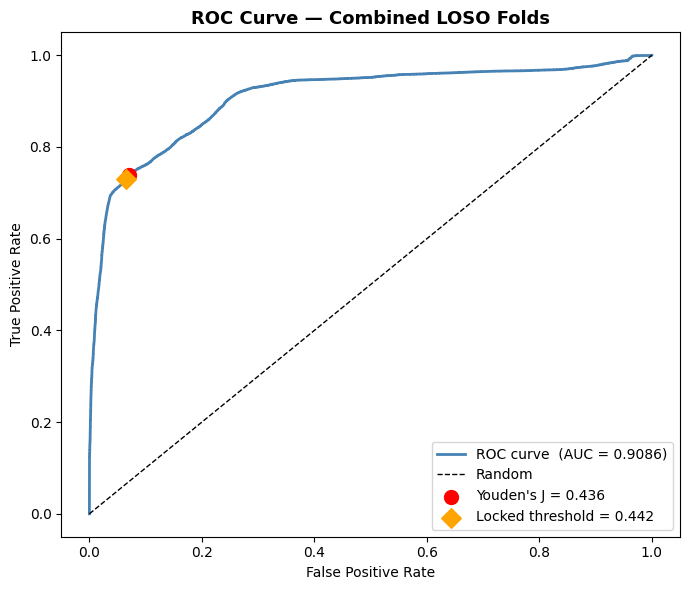

Overall AUC              : 0.9086
Youden's J threshold     : 0.4361  (TPR=0.7390, FPR=0.0707)
Locked generic threshold : 0.442  (TPR=0.7292, FPR=0.0647)


In [20]:
fpr, tpr, roc_thresholds = roc_curve(all_true_arr, all_prob_arr)
auc_overall = roc_auc_score(all_true_arr, all_prob_arr)

j_scores      = tpr - fpr
best_j_idx    = np.argmax(j_scores)
best_j_thresh = float(roc_thresholds[best_j_idx])

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'ROC curve  (AUC = {auc_overall:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.scatter(fpr[best_j_idx], tpr[best_j_idx], color='red', zorder=5, s=100,
           label=f"Youden's J = {best_j_thresh:.3f}")

# Mark the locked generic threshold
idx_locked = np.argmin(np.abs(roc_thresholds - LOCKED_THRESHOLD))
ax.scatter(fpr[idx_locked], tpr[idx_locked], color='orange', zorder=5, s=100,
           marker='D', label=f'Locked threshold = {LOCKED_THRESHOLD}')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Combined LOSO Folds', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall AUC              : {auc_overall:.4f}')
print(f"Youden's J threshold     : {best_j_thresh:.4f}  "
      f"(TPR={tpr[best_j_idx]:.4f}, FPR={fpr[best_j_idx]:.4f})")
print(f'Locked generic threshold : {LOCKED_THRESHOLD}  '
      f"(TPR={tpr[idx_locked]:.4f}, FPR={fpr[idx_locked]:.4f})")


## 13. Per-Subject Accuracy & F1 Bar Charts (Phase 3)

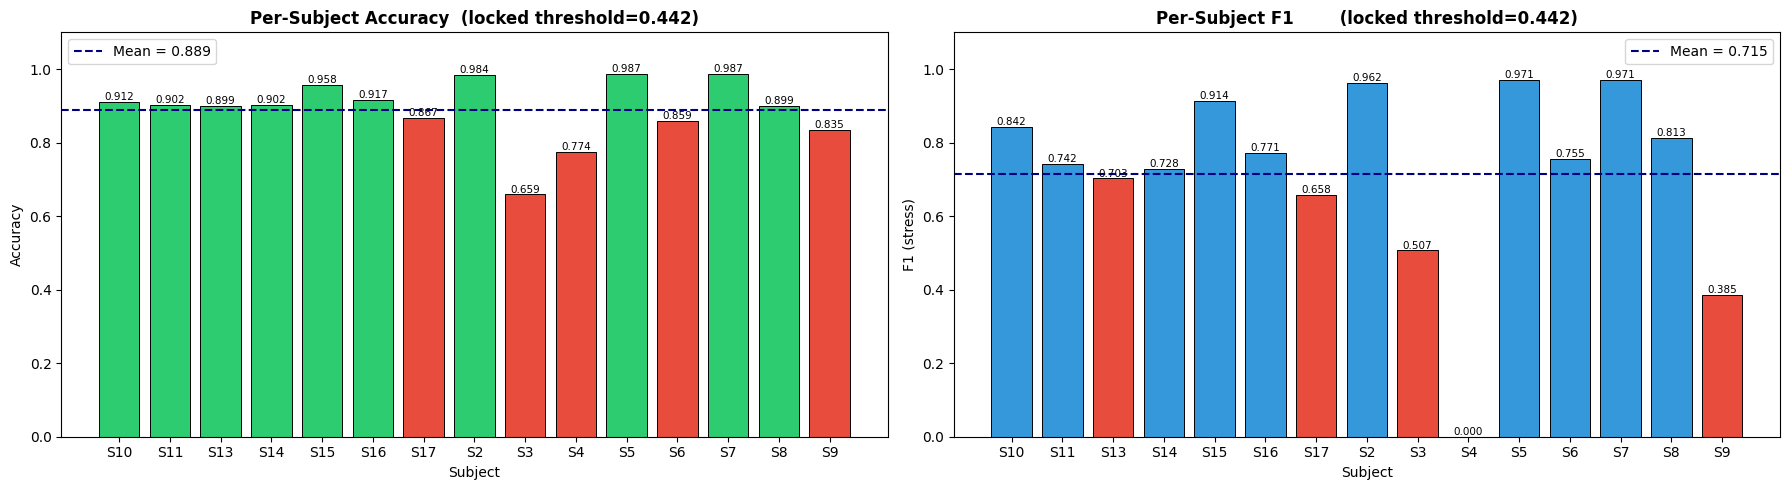

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, col, mean_val, color_hi, color_lo, ylabel, title in [
    (axes[0], 'acc_phase3', mean_acc_p3, '#2ecc71', '#e74c3c',
     'Accuracy',    f'Per-Subject Accuracy  (locked threshold={LOCKED_THRESHOLD})'),
    (axes[1], 'f1_phase3',  mean_f1_p3,  '#3498db', '#e74c3c',
     'F1 (stress)', f'Per-Subject F1        (locked threshold={LOCKED_THRESHOLD})'),
]:
    colors_bar = [color_hi if v >= mean_val else color_lo for v in phase3_df[col]]
    bars = ax.bar(phase3_df['subject'], phase3_df[col],
                  color=colors_bar, edgecolor='black', linewidth=0.7)
    ax.axhline(mean_val, color='navy', linestyle='--', lw=1.5,
               label=f'Mean = {mean_val:.3f}')
    for bar, val in zip(bars, phase3_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=7.5)
    ax.set_xlabel('Subject')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.10)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, f'per_subject_locked_{LOCKED_THRESHOLD:.4f}.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## 14. Saved Models Summary & How to Reload

In [22]:
saved_models = sorted([f for f in os.listdir(MODELS_PATH) if f.endswith('.keras')])
print('── Saved models ──')
for fname in saved_models:
    fpath   = os.path.join(MODELS_PATH, fname)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f'  {fname:<42s}  {size_mb:.1f} MB')

print(f'\n★ Best fold : subject={best_model_info["subject"]}  '
      f'F1={best_model_info["f1"]:.4f}  Acc={best_model_info["acc"]:.4f}')

print()
print('── How to reload and run inference ──')
print(f"""
from tensorflow.keras.models import load_model
import tensorflow as tf
import numpy as np

def focal_loss(gamma=2.0, alpha=0.25):
    def _focal(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce_pos = -tf.math.log(y_pred)
        ce_neg = -tf.math.log(1.0 - y_pred)
        fl_pos = alpha       * tf.pow(1.0 - y_pred, gamma) * ce_pos
        fl_neg = (1 - alpha) * tf.pow(y_pred,        gamma) * ce_neg
        return tf.reduce_mean(y_true * fl_pos + (1.0 - y_true) * fl_neg)
    return _focal

LOCKED_THRESHOLD = {LOCKED_THRESHOLD}   # generic model threshold from Phase 2

model = load_model('{MODELS_PATH}/best_fold_model.keras',
                   custom_objects={{'_focal': focal_loss()}})

# Inference: chest (1,3500,5) and wrist (1,320,6), per-subject z-scored
prob  = model.predict([chest_window, wrist_window])[0, 0]
label = int(prob >= LOCKED_THRESHOLD)
print("stress" if label == 1 else "non-stress", f"(prob={{prob:.3f}})")
""")


── Saved models ──
  best_fold_model.keras                       2.2 MB
  cnn_fold_S10.keras                          2.2 MB
  cnn_fold_S11.keras                          2.2 MB
  cnn_fold_S13.keras                          2.2 MB
  cnn_fold_S14.keras                          2.2 MB
  cnn_fold_S15.keras                          2.2 MB
  cnn_fold_S16.keras                          2.2 MB
  cnn_fold_S17.keras                          2.2 MB
  cnn_fold_S2.keras                           2.2 MB
  cnn_fold_S3.keras                           2.2 MB
  cnn_fold_S4.keras                           2.2 MB
  cnn_fold_S5.keras                           2.2 MB
  cnn_fold_S6.keras                           2.2 MB
  cnn_fold_S7.keras                           2.2 MB
  cnn_fold_S8.keras                           2.2 MB
  cnn_fold_S9.keras                           2.2 MB

★ Best fold : subject=S5  F1=0.9981  Acc=0.9992

── How to reload and run inference ──

from tensorflow.keras.models import load_mod

## 15. Save Comparison-Ready CSVs

In [23]:
# Full Phase 3 per-subject results — use for paper table
comparison_df = phase3_df[['subject','locked_threshold','acc_phase3','f1_phase3',
                             'auc_phase3','acc_phase1','f1_phase1','fold_threshold',
                             'approach','task']].copy()
comparison_df.rename(columns={
    'acc_phase3': 'accuracy', 'f1_phase3': 'f1', 'auc_phase3': 'auc'
}, inplace=True)
comparison_path = os.path.join(OUTPUT_PATH, 'cnn_final_comparison_ready.csv')
comparison_df.to_csv(comparison_path, index=False)
print(f'✓ saved: {comparison_path}')

# Consolidated summary for both phases
all_summary = pd.concat([phase2_summary, phase3_summary], ignore_index=True)
all_summary_path = os.path.join(OUTPUT_PATH, 'cnn_all_phases_summary.csv')
all_summary.to_csv(all_summary_path, index=False)
print(f'✓ saved: {all_summary_path}')
print()
print('═' * 70)
print('FINAL REPORTING SUMMARY')
print('═' * 70)
print()
print('Report in your paper:')
print(f'  Model         : Dual-stream 1D CNN (chest + wrist), focal loss, v3')
print(f'  Protocol      : LOSO, Gold Standard 3-Phase CV')
print(f'  Threshold     : {LOCKED_THRESHOLD} (mean of per-fold val thresholds; std={std_threshold:.3f})')
print()
print('  Phase 1 results (fold-specific threshold — optimistic upper bound):')
print(f'    Accuracy = {mean_acc:.4f} ± {std_acc:.4f}')
print(f'    F1       = {mean_f1:.4f} ± {std_f1:.4f}')
print(f'    AUC      = {mean_auc:.4f} ± {std_auc:.4f}')
print()
print('  Phase 3 results (locked generic threshold — honest generic result):')
print(f'    Accuracy = {mean_acc_p3:.4f} ± {std_acc_p3:.4f}')
print(f'    F1       = {mean_f1_p3:.4f} ± {std_f1_p3:.4f}')
print(f'    AUC      = {mean_auc_p3:.4f}')


✓ saved: WESAD/output_v4/cnn_final_comparison_ready.csv
✓ saved: WESAD/output_v4/cnn_all_phases_summary.csv

══════════════════════════════════════════════════════════════════════
FINAL REPORTING SUMMARY
══════════════════════════════════════════════════════════════════════

Report in your paper:
  Model         : Dual-stream 1D CNN (chest + wrist), focal loss, v3
  Protocol      : LOSO, Gold Standard 3-Phase CV
  Threshold     : 0.442 (mean of per-fold val thresholds; std=0.111)

  Phase 1 results (fold-specific threshold — optimistic upper bound):
    Accuracy = 0.8951 ± 0.0957
    F1       = 0.7981 ± 0.1551
    AUC      = 0.9104 ± 0.1120

  Phase 3 results (locked generic threshold — honest generic result):
    Accuracy = 0.8893 ± 0.0868
    F1       = 0.7148 ± 0.2578
    AUC      = 0.9104
